# Batch2_analysis.ipynb Battery Analysis

목표:
- 초기 100 cycle 기반 feature 생성
- 이상값 제거
- correlation 분석
- regression 준비


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.io as sio
import mat73


## 데이터 로딩

In [2]:
def load_mat(path):
    try:
        data = mat73.loadmat(path)
    except:
        data = sio.loadmat(path, simplify_cells=True)
    return data

DATA_DIR=Path('../data/data-30')

In [3]:
def extract_cells(batch):

    cells=[]

    n=len(batch['cycle_life'])

    for i in range(n):

        cell={}

        for key in batch.keys():

            value=batch[key]

            if isinstance(value,list):

                cell[key]=value[i]

            else:

                cell[key]=value

        cells.append(cell)

    return cells

In [ ]:
DATA_DIR=Path("../data/data-30")

b2=load_mat(DATA_DIR/"2018-02-20_batchdata_updated_struct_errorcorrect.mat")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

## Feature Engineering (100 cycle 기준)

In [5]:
def early_mean(arr,n=100):
    arr=np.array(arr).reshape(-1)
    if len(arr)<n:
        return np.nan
    return np.mean(arr[:n])

def delta_100(arr):
    arr=np.array(arr).reshape(-1)
    if len(arr)<100:
        return np.nan
    return arr[99]-arr[0]

def delta_100_10(arr):
    arr=np.array(arr).reshape(-1)
    if len(arr)<100:
        return np.nan
    return arr[99]-arr[9]

def early_var(arr,n=100):
    arr=np.array(arr).reshape(-1)
    if len(arr)<n:
        return np.nan
    return np.var(arr[:n])

## Feature DataFrame 생성

In [6]:
def build_feature_df(cells):
    rows=[]
    for cell in cells:
        summary=cell['summary']
        row={
        'cycle_life':cell['cycle_life'],
        'IR_mean':early_mean(summary['IR']),
        'QDischarge_mean':early_mean(summary['QDischarge']),
        'Tmax_mean':early_mean(summary['Tmax']),
        'Tavg_mean':early_mean(summary['Tavg']),
        'charge_time_mean':early_mean(summary['chargetime']),
        'IR_delta':delta_100(summary['IR']),
        'QDischarge_delta':delta_100(summary['QDischarge']),
        'IR_delta_100_10':delta_100_10(summary['IR']),
        'QDischarge_delta_100_10':delta_100_10(summary['QDischarge']),
        'IR_var':early_var(summary['IR']),
        'QDischarge_var':early_var(summary['QDischarge'])
        }
        rows.append(row)
    return pd.DataFrame(rows)

## NaN 제거

In [7]:
cells = extract_cells(b2['batch'])
df = build_feature_df(cells)
df=df.dropna()
df.head()

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta,IR_delta_100_10,QDischarge_delta_100_10,IR_var,QDischarge_var
0,477.0,0.017338,1.105038,35.361941,31.807497,10.173261,-0.000096,0.005192,0.000050,0.001554,1.476332e-08,0.000010
1,491.0,0.017559,1.104946,36.448097,33.598303,10.199074,-0.000756,-0.005669,-0.000320,-0.006769,3.187804e-08,0.000012
2,424.0,0.016463,1.074656,37.427645,33.177566,10.175028,-0.000122,-0.001128,0.000185,-0.005760,1.056783e-08,0.000125
3,499.0,0.015917,1.101432,38.773129,33.939585,10.173197,-0.000043,0.004143,0.000261,0.001901,8.617927e-09,0.000009
4,444.0,0.016196,1.085958,37.433836,33.050272,10.231934,-0.000972,-0.007804,-0.000261,-0.009355,4.890719e-08,0.000010


## 그래프 1 : cycle life 분포

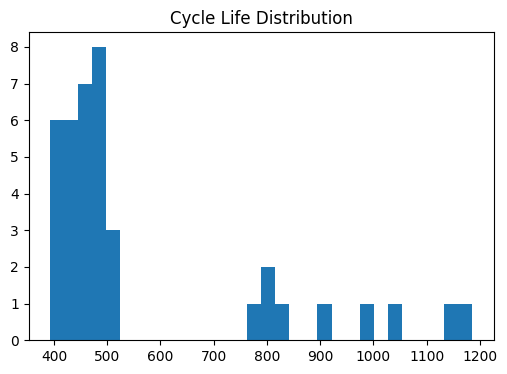

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df['cycle_life'],bins=30)
plt.title('Cycle Life Distribution')
plt.show()

## 그래프 2 : feature histogram

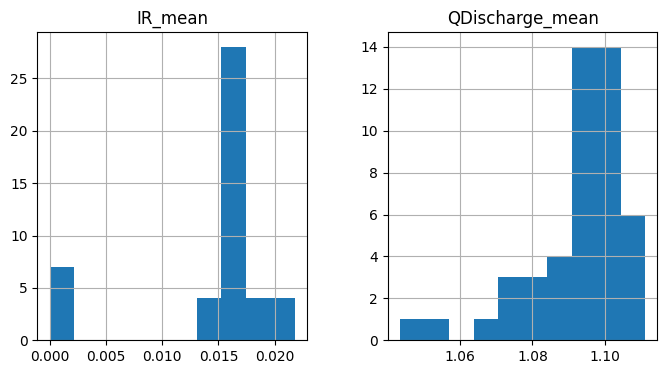

In [9]:
df[['IR_mean','QDischarge_mean']].hist(figsize=(8,4))
plt.show()

## 그래프 3 : Correlation heatmap

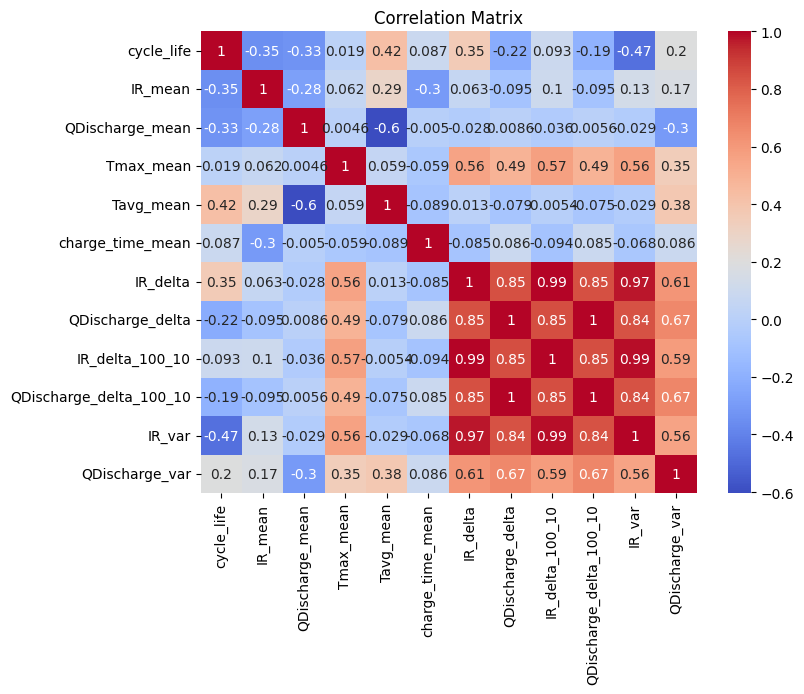

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 그래프 4 : Scatter

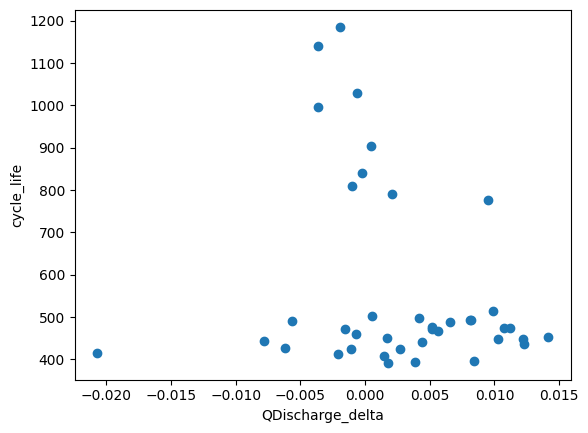

In [11]:
plt.scatter(df['QDischarge_delta'],df['cycle_life'])
plt.xlabel('QDischarge_delta')
plt.ylabel('cycle_life')
plt.show()

In [13]:
df.to_csv("../results/batch2_features.csv",index=False)